# Más allá de las cifras: un análisis de la tasa de suicidio y sus factores asociados.

### Motivación y contexto:

La salud mental es un tema que en los últimos años ha adquirido una creciente importancia tanto en la investigación como en la vida cotidiana. Actualmente, existe una mayor visibilidad de problemáicas como la ansiedad, la depresión y otros trastornos asociados, lo que ha generado la percepción de que estos problemas han aumentado con el tiempo. Sin embargo, surge una interrogante importante: ¿este aumento refleja un deterioro real en la salud mental de la población o es consecuencia de una mayor visibilización y mejores diagnósticos?

Esta interrogante fue el punto de partida de nuestro interés en el tema. Al investigar el impacto más severo de estas patologías, nos encontramos con cifras alarmantes publicadas por la Organización Mundial de la Salud (OMS) en su [Articulo sobre el suicidio](https://www.who.int/es/news-room/fact-sheets/detail/suicide). Según la organización, cada año fallecen más de 720000 personas por esta causa, lo que representa una gran problema a la salud publica. La OMS destaca que el suicidio es un fenómeno multifactorial, donde convergen elementos biológicos, psicológicos, sociales y culturales a lo largo de la vida de una persona.

En este contexto, el análisis de datos se vuelve una herramienta clave para abordar esta problemática desde una perspectiva objetiva. En particular, la tasa de suicidio es uno de los indicadores más utilizados en salud pública, ya que permite aproximarse de manera cuantificable a la evolución de la salud mental en distintas poblaciones y periodos de tiempo.

De esta forma, se busca no solo estudiar la evolución de la tasa de suicidio a nivel global, sino también identificar posibles patrones y relaciones entre este indicador y distintas variables relevantes. Esto permitirá aportar una visión más completa y basada en datos al análisis de la salud mental en el contexto actual.

### Objetivos

El objetivo principal de este proyecto es analizar la evolución de la tasa de suicidio a nivel global a lo largo del tiempo, con el fin de identificar cambios en los indicadores de salud mental y su posible relación con factores socioeconómicos y de acceso a la salud.

De manera específica, se busca:

- Analizar la tendencia temporal de la tasa de suicidio en distintos países.

- Comparar la evolución de este indicador entre diferentes periodos de tiempo y contextos.

- Estudiar la relación entre la tasa de suicidio y variables como economicas, desempleo, y genero.

- Aplicar herramientas estadísticas para evaluar la existencia de relaciones significativas entre estas variables.

- Construir un modelo predictivo que permita estimar tendencias futuras de la tasa de suicidio.

- Interpretar los resultados en el contexto de factores sociales, económicos y culturales.

### Preguntas objetivo

## Pregunta general

**¿Cómo se relacionan las condiciones económicas, el género y el desempleo con las tasas de suicidio a nivel país-año, y qué tan bien estas variables permiten predecir países-año con tasas altas de suicidio?**

## Pregunta 1 — Economía

**¿Cómo varía la tasa de suicidios entre países-año con distintos niveles de economía?**

Esta pregunta busca analizar si existen diferencias en la tasa de suicidios según el nivel económico del país-año observado, usando la pobreza extrema como indicador económico principal.

## Pregunta 2 — Género

**¿Existen diferencias sistemáticas en las tasas de suicidio entre hombres y mujeres a nivel país-año?**

## Pregunta 3 — Desempleo

**¿Existe una asociación entre la tasa de desempleo y la tasa de suicidios a nivel país-año?**

## Pregunta 4 — Modelo predictivo

**¿Qué tan bien se puede predecir si un país-año presenta una tasa alta de suicidio usando únicamente variables de pobreza extrema, género y desempleo?**

Ya en esta parte comenzaremos con el análisis de los datos. La idea principal del proyecto es dividir el trabajo en tres grandes etapas:

1. ETL (Extract, Transform, Load): limpieza, integración y preparación de los datos.

2. EDA (Exploratory Data Analysis): exploración de los datos mediante gráficos, correlaciones y búsqueda de patrones.

3. Modelado e inferencia: construcción del modelo predictivo.


**Extract:**

En esta etapa simplemente cargaremos los datasets y revisaremos su contenido inicial.

*Librerias*

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
# Cargar los archivos CSV.
df_eco = pd.read_csv(r"data\economia\homicidios_suicidios.csv", encoding="utf-8")

df_desempleo = pd.read_csv(r"data\Desempleo\unemployment-rate.csv", encoding="utf-8")

df_genero = pd.read_csv(r"data\genero\age_std_suicide_rates_1990-2022.csv", encoding="utf-8")

# Columnas que se usarán en cada DataFrame
cols_eco = [
    "country",
    "iso3c",
    "year",
    "Suicide mortality rate (per 100,000 population)",
    "GDP per capita, PPP (current international $)",
    "adminregion",
    "incomeLevel"
]

cols_genero = [
    "RegionName",
    "CountryCode",
    "CountryName",
    "Year",
    "Sex",
    "SuicideCount",
    "DeathRatePer100K",
    "StdDeathRate",
    "Population"
]

# Dejar solo las columnas necesarias
df_eco = df_eco[cols_eco]
df_genero = df_genero[cols_genero]


## Limpieza

### `1. Tipos de datos`

In [3]:
# Cambiar tipos de datos en df_eco
df_eco = df_eco.astype({
    "country": str,
    "iso3c": str,
    "year": int,
    "Suicide mortality rate (per 100,000 population)": float,
    "GDP per capita, PPP (current international $)": float,
    "adminregion": str,
    "incomeLevel": str
})

# Cambiar tipos de datos en df_desempleo
df_desempleo = df_desempleo.astype({
    "Entity": str,
    "Code": str,
    "Year": int,
    "Unemployment rate": float
})

# Cambiar tipos de datos en df_genero
df_genero = df_genero.astype({
    "RegionName": str,
    "CountryCode": str,
    "CountryName": str,
    "Year": int,
    "Sex": str,
    "SuicideCount": int,
    "DeathRatePer100K": float,
    "StdDeathRate": float,
    "Population": float
})

### `2. Datos faltantes`

**Economico**

In [4]:
df_eco.isnull().sum()

country                                               0
iso3c                                               102
year                                                  0
Suicide mortality rate (per 100,000 population)    8946
GDP per capita, PPP (current international $)      6328
adminregion                                        6579
incomeLevel                                         102
dtype: int64

In [5]:
df_eco_limpio = df_eco.copy()

# Eliminar registros sin código de país
df_eco_limpio = df_eco_limpio.dropna(subset=["iso3c"])

# Eliminar registros sin nivel de ingreso
df_eco_limpio = df_eco_limpio.dropna(subset=["incomeLevel"])

# Rellenar región faltante
df_eco_limpio["adminregion"] = df_eco_limpio["adminregion"].fillna("Sin región")

# Versión opcional para análisis con PIB per cápita
df_eco_gdp = df_eco_limpio.dropna(
    subset=["GDP per capita, PPP (current international $)"]
)

# Versión opcional para análisis general de tasa de suicidio
df_eco_suicidio = df_eco_limpio.dropna(
    subset=["Suicide mortality rate (per 100,000 population)"]
)

df_eco_limpio.isnull().sum()

country                                               0
iso3c                                                 0
year                                                  0
Suicide mortality rate (per 100,000 population)    8884
GDP per capita, PPP (current international $)      6288
adminregion                                           0
incomeLevel                                           0
dtype: int64

Se eliminaron los registros sin código de país, ya que el código ISO3 es necesario para unir esta base con las demás fuentes de datos. Además, estos registros suelen corresponder a agregados o categorías que no representan países individuales.

Se eliminaron los registros sin nivel de ingreso, porque esta variable representa una dimensión central del análisis socioeconómico y no es recomendable asignarla manualmente sin una fuente externa.

Los valores nulos en PIB per cápita se mantuvieron inicialmente para no perder información útil de otras variables, como nivel de ingreso o región. Para los análisis que requieran específicamente PIB per cápita, se trabajará con una versión filtrada que contenga solo los registros con ese dato disponible.

Los valores faltantes en región administrativa fueron reemplazados por “Sin región”, ya que esta variable se usará principalmente para agrupar o describir los datos, pero no como variable principal del análisis. Esto permite conservar observaciones que sí tienen información relevante en otras columnas.

Los valores nulos en la tasa de suicidio de df_eco no fueron rellenados, ya que corresponden a datos no disponibles. Para el análisis principal se utilizará la tasa de suicidio de df_genero, porque permite comparar por sexo. La tasa de df_eco se podrá usar solo como referencia general cuando esté disponible.

**Desempleo**

In [6]:
df_desempleo.isnull().sum()

Entity               0
Code                 0
Year                 0
Unemployment rate    0
dtype: int64

**Genero**

In [7]:
df_genero.isnull().sum()

RegionName            0
CountryCode           0
CountryName           0
Year                  0
Sex                   0
SuicideCount          0
DeathRatePer100K    208
StdDeathRate        208
Population          296
dtype: int64

In [8]:
df_genero_limpio = df_genero.copy()

# Intentar calcular DeathRatePer100K cuando falte, usando SuicideCount y Population
mask = (
    df_genero_limpio["DeathRatePer100K"].isna()
    & df_genero_limpio["Population"].notna()
    & (df_genero_limpio["Population"] > 0)
)

df_genero_limpio.loc[mask, "DeathRatePer100K"] = (
    df_genero_limpio.loc[mask, "SuicideCount"]
    / df_genero_limpio.loc[mask, "Population"]
) * 100000

# Eliminar filas que aún no tienen tasa de suicidio
df_genero_limpio = df_genero_limpio.dropna(subset=["DeathRatePer100K"])

df_genero_limpio.isnull().sum()

RegionName            0
CountryCode           0
CountryName           0
Year                  0
Sex                   0
SuicideCount          0
DeathRatePer100K      0
StdDeathRate        204
Population          292
dtype: int64

Cuando faltaba la tasa de suicidio por 100.000 habitantes, se intentó calcularla usando el número de suicidios y la población disponible. Esto permite recuperar observaciones sin inventar datos, ya que la tasa se obtiene directamente a partir de variables presentes en la misma base.

Los registros que seguían sin tasa de suicidio después del cálculo fueron eliminados, ya que la tasa es la variable principal del análisis y no es recomendable reemplazarla por promedios o ceros, porque eso podría distorsionar los resultados.

Los valores faltantes en población no se eliminaron de inmediato, porque el análisis principal se basa en tasas por 100.000 habitantes. Si la tasa ya está disponible, la observación sigue siendo útil. La población solo se filtrará en análisis donde sea estrictamente necesaria.

### `3. Renombrar columnas`

In [9]:
# Renombrar columnas de df_eco_limpio
df_eco_limpio = df_eco_limpio.rename(columns={
    "country": "pais",
    "iso3c": "codigo_pais",
    "year": "anio",
    "Suicide mortality rate (per 100,000 population)": "tasa_suicidio_general_100k",
    "GDP per capita, PPP (current international $)": "pib_per_capita_ppp",
    "adminregion": "region",
    "incomeLevel": "nivel_ingreso"
})

# Renombrar columnas de df_desempleo_limpio
df_desempleo_limpio = df_desempleo.rename(columns={
    "Entity": "pais",
    "Code": "codigo_pais",
    "Year": "anio",
    "Unemployment rate": "tasa_desempleo"
})

# Renombrar columnas de df_genero_limpio
df_genero_limpio = df_genero_limpio.rename(columns={
    "RegionName": "region",
    "CountryCode": "codigo_pais",
    "CountryName": "pais",
    "Year": "anio",
    "Sex": "sexo",
    "SuicideCount": "cantidad_suicidios",
    "DeathRatePer100K": "tasa_suicidio_genero_100k",
    "StdDeathRate": "tasa_suicidio_estandarizada",
    "Population": "poblacion"
})

**Revisamos los codigos de pais**

In [10]:
df_genero_limpio["codigo_pais"]

0       ALB
1       ALB
2       ALB
3       ALB
4       ALB
       ... 
5923    MYT
5924    REU
5925    REU
5926    REU
5927    REU
Name: codigo_pais, Length: 5924, dtype: str

In [11]:
df_eco_limpio["codigo_pais"]

0        AFG
1        AFG
2        AFG
3        AFG
4        AFG
        ... 
13561    ZWE
13562    ZWE
13563    ZWE
13564    ZWE
13565    ZWE
Name: codigo_pais, Length: 13464, dtype: str

In [12]:
df_desempleo_limpio["codigo_pais"]

0       AFG
1       AFG
2       AFG
3       AFG
4       AFG
       ... 
6981    ZWE
6982    ZWE
6983    ZWE
6984    ZWE
6985    ZWE
Name: codigo_pais, Length: 6986, dtype: str

### `4. Duplicados`

In [13]:
# Duplicados exactos en cada DataFrame
print("Duplicados exactos df_eco_limpio:", df_eco_limpio.duplicated().sum())
print("Duplicados exactos df_desempleo_limpio:", df_desempleo_limpio.duplicated().sum())
print("Duplicados exactos df_genero_limpio:", df_genero_limpio.duplicated().sum())

Duplicados exactos df_eco_limpio: 0
Duplicados exactos df_desempleo_limpio: 0
Duplicados exactos df_genero_limpio: 0


### `5. Filtrado de columnas`

En esta etapa se revisaron las columnas disponibles en cada base de datos y se seleccionaron solo aquellas que eran útiles para el objetivo del proyecto. Como el análisis busca estudiar la tasa de suicidio en relación con variables socioeconómicas, desempleo y género, se conservaron columnas como país, código del país, año, tasa de suicidio, PIB per cápita, nivel de ingreso, tasa de desempleo, sexo, cantidad de suicidios, tasa de suicidio por cada 100.000 habitantes y población.

Las columnas que no aportaban directamente al análisis o que podían repetir información fueron descartadas. Esta decisión permite trabajar con bases más simples, ordenadas y enfocadas en la pregunta de investigación.

### `6. Rangos y paises`

Para unir los df primero tendremos que definir un rango de fechas y un conjuntos  de paises que toda nuestra base de datos contenga, para ello creamos una funcion llamada rangos:

**Descripción:**
Esta función determina la intersección de conjuntos de los valores únicos de una columna específica a lo largo de una lista de DataFrames. Su objetivo principal es identificar qué elementos coexisten y se repiten de manera transversal en todas la base de datos para poder hacer las unines pertinentes.

Gracias esta funcion obtendremos un set con todas las fechas y paises en comun. Como podemos notar tenemos un rango desde los 2000 - 2020 un buen rango que nos da una buena infromacion para trabajar los datos. 

In [14]:
df_desempleo_limpio.columns

Index(['pais', 'codigo_pais', 'anio', 'tasa_desempleo'], dtype='str')

In [15]:
# ============================================================
# FILTRAR PAÍSES Y AÑOS COMUNES ENTRE LAS TRES BASES
# ============================================================

# Lista de DataFrames limpios
lista_df = [
    df_eco_limpio,
    df_desempleo_limpio,
    df_genero_limpio
]

 
# 1. Función para obtener valores comunes entre DataFrames


def valores_comunes(variable: str, lista_dfs: list) -> set:
    valores = set(lista_dfs[0][variable].dropna().unique())

    for df in lista_dfs[1:]:
        valores_df = set(df[variable].dropna().unique())
        valores = valores.intersection(valores_df)

    return valores



# 2. Obtener países y años comunes


anios_comunes = valores_comunes("anio", lista_df)
paises_comunes = valores_comunes("codigo_pais", lista_df)

print("Cantidad de años comunes:", len(anios_comunes))
print("Años comunes:", sorted(anios_comunes))
print("Cantidad de países comunes:", len(paises_comunes))



# 3. Crear intervalo completo de años
 

anio_inicio = min(anios_comunes)
anio_fin = max(anios_comunes)

intervalo_anios = set(range(anio_inicio, anio_fin + 1))

print("\nIntervalo de años propuesto:")
print(anio_inicio, "-", anio_fin)

# Revisar si faltan años dentro del intervalo
anios_faltantes = intervalo_anios - anios_comunes

if len(anios_faltantes) > 0:
    print("\nOjo: faltan años dentro del intervalo común:")
    print(sorted(anios_faltantes))
    print("Se usará solo el conjunto de años comunes disponibles.")
    intervalo_anios = anios_comunes
else:
    print("\nEl intervalo de años está completo.")


 
# 4. Función para encontrar países con todos los años
   

def paises_con_anios_completos(df, anios, col_pais="codigo_pais", col_anio="anio"):
    df_filtrado = df[df[col_anio].isin(anios)].copy()

    conteo_anios = df_filtrado.groupby(col_pais)[col_anio].nunique()

    paises_completos = set(
        conteo_anios[conteo_anios == len(anios)].index
    )

    return paises_completos


   
# 5. Función especial para género
#    Exige país + año + sexo
   

def paises_con_genero_completo(df, anios, sexos):
    df_filtrado = df[
        (df["anio"].isin(anios)) &
        (df["sexo"].isin(sexos))
    ].copy()

    df_filtrado = df_filtrado.drop_duplicates(
        subset=["codigo_pais", "anio", "sexo"]
    )

    conteo = df_filtrado.groupby("codigo_pais").size()

    paises_completos = set(
        conteo[conteo == len(anios) * len(sexos)].index
    )

    return paises_completos


   
# 6. Definir sexos que se usarán en el análisis
   

sexos_disponibles = set(df_genero_limpio["sexo"].dropna().unique())

# Si existen Male y Female, usamos solo esos para el análisis por género
if {"Male", "Female"}.issubset(sexos_disponibles):
    sexos_analisis = ["Male", "Female"]
else:
    sexos_analisis = sorted(sexos_disponibles)

print("\nSexos usados en el análisis:")
print(sexos_analisis)


   
# 7. Obtener países que tienen todos los años en cada base
 

paises_eco_completos = paises_con_anios_completos(
    df_eco_limpio,
    intervalo_anios
)

paises_desempleo_completos = paises_con_anios_completos(
    df_desempleo_limpio,
    intervalo_anios
)

paises_genero_completos = paises_con_genero_completo(
    df_genero_limpio,
    intervalo_anios,
    sexos_analisis
)

# Países finales: deben estar en las tres bases y tener años completos
paises_finales = (
    paises_comunes
    .intersection(paises_eco_completos)
    .intersection(paises_desempleo_completos)
    .intersection(paises_genero_completos)
)

print("\nCantidad de países finales con datos completos:")
print(len(paises_finales))


 
# 8. Filtrar los DataFrames
   

df_eco_filtrado = df_eco_limpio[
    (df_eco_limpio["codigo_pais"].isin(paises_finales)) &
    (df_eco_limpio["anio"].isin(intervalo_anios))
].copy()

df_desempleo_filtrado = df_desempleo_limpio[
    (df_desempleo_limpio["codigo_pais"].isin(paises_finales)) &
    (df_desempleo_limpio["anio"].isin(intervalo_anios))
].copy()

df_genero_filtrado = df_genero_limpio[
    (df_genero_limpio["codigo_pais"].isin(paises_finales)) &
    (df_genero_limpio["anio"].isin(intervalo_anios)) &
    (df_genero_limpio["sexo"].isin(sexos_analisis))
].copy()


   
# 9. Revisar resultados finales
   

print("\nResumen df_eco_filtrado:")
print("Filas:", df_eco_filtrado.shape[0])
print("Países:", df_eco_filtrado["codigo_pais"].nunique())
print("Años:", df_eco_filtrado["anio"].min(), "-", df_eco_filtrado["anio"].max())

print("\nResumen df_desempleo_filtrado:")
print("Filas:", df_desempleo_filtrado.shape[0])
print("Países:", df_desempleo_filtrado["codigo_pais"].nunique())
print("Años:", df_desempleo_filtrado["anio"].min(), "-", df_desempleo_filtrado["anio"].max())

print("\nResumen df_genero_filtrado:")
print("Filas:", df_genero_filtrado.shape[0])
print("Países:", df_genero_filtrado["codigo_pais"].nunique())
print("Años:", df_genero_filtrado["anio"].min(), "-", df_genero_filtrado["anio"].max())
print("Sexos:", df_genero_filtrado["sexo"].unique())


   
# 10. Verificar que cada país tenga todos los años
   

print("\nAños por país en df_eco_filtrado:")
print(df_eco_filtrado.groupby("codigo_pais")["anio"].nunique().value_counts())

print("\nAños por país en df_desempleo_filtrado:")
print(df_desempleo_filtrado.groupby("codigo_pais")["anio"].nunique().value_counts())

print("\nRegistros país-año-sexo en df_genero_filtrado:")
print(
    df_genero_filtrado
    .drop_duplicates(subset=["codigo_pais", "anio", "sexo"])
    .groupby("codigo_pais")
    .size()
    .value_counts()
)

Cantidad de años comunes: 30
Años comunes: [np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Cantidad de países comunes: 107

Intervalo de años propuesto:
1991 - 2020

El intervalo de años está completo.

Sexos usados en el análisis:
['Male', 'Female']

Cantidad de países finales con datos completos:
40

Resumen df_eco_filtrado:
Filas: 1200
Países: 40
Años: 1991 - 2020

Resumen df_desempleo_filtrado:
Filas: 1200
Países: 40
Años: 1991 - 2020

Resumen df_genero_filtrado:
Filas: 2400
Países: 40
Años: 1991 - 2020
Sexos: <ArrowStringArray>
['Male', 'Female']
Length: 2

### `7. Unir los Dfs`

In [16]:
# 1. Seleccionar columnas necesarias de cada base

# Base socioeconómica
df_eco_union = df_eco_filtrado[
    [
        "codigo_pais",
        "anio",
        "tasa_suicidio_general_100k",
        "pib_per_capita_ppp",
        "region",
        "nivel_ingreso"
    ]
].copy()

# Para evitar confusión con la región de df_genero
df_eco_union = df_eco_union.rename(columns={
    "region": "region_socioeconomica"
})

# Base desempleo
df_desempleo_union = df_desempleo_filtrado[
    [
        "codigo_pais",
        "anio",
        "tasa_desempleo"
    ]
].copy()

# Base genero
df_genero_union = df_genero_filtrado[
    [
        "codigo_pais",
        "pais",
        "region",
        "anio",
        "sexo",
        "cantidad_suicidios",
        "tasa_suicidio_genero_100k",
        "tasa_suicidio_estandarizada",
        "poblacion"
    ]
].copy()

df_genero_union = df_genero_union.rename(columns={
    "region": "region_genero"
})
   
# 2. Revisar que no haya duplicados antes de unir

print("Duplicados df_eco_union por país-año:")
print(df_eco_union.duplicated(subset=["codigo_pais", "anio"]).sum())

print("\nDuplicados df_desempleo_union por país-año:")
print(df_desempleo_union.duplicated(subset=["codigo_pais", "anio"]).sum())

print("\nDuplicados df_genero_union por país-año-sexo:")
print(df_genero_union.duplicated(subset=["codigo_pais", "anio", "sexo"]).sum())
   
# 3. Unir base socioeconómica con desempleo
#    Ambas tienen una fila por país-año

df_socioeconomico = df_eco_union.merge(
    df_desempleo_union,
    on=["codigo_pais", "anio"],
    how="inner",
    validate="one_to_one"
)

print("\nTamaño df_socioeconomico:")
print(df_socioeconomico.shape)

# 4. Unir la base por género con la base socioeconómica
#    df_genero tiene varias filas por país-año porque existe una por sexo

df_final = df_genero_union.merge(
    df_socioeconomico,
    on=["codigo_pais", "anio"],
    how="inner",
    validate="many_to_one"
)

print("\nTamaño df_final:")
print(df_final.shape)

# 5. Ordenar columnas finales

df_final = df_final[
    [
        "codigo_pais",
        "pais",
        "anio",
        "sexo",
        "region_genero",
        "region_socioeconomica",
        "nivel_ingreso",
        "cantidad_suicidios",
        "tasa_suicidio_genero_100k",
        "tasa_suicidio_estandarizada",
        "tasa_suicidio_general_100k",
        "poblacion",
        "tasa_desempleo",
        "pib_per_capita_ppp"
    ]
]

# 6. Revisar resultado final
   
print("\nPrimeras filas de df_final:")
display(df_final.head())

print("\nInformación general:")
print(df_final.info())

print("\nValores nulos en df_final:")
print(df_final.isnull().sum())

print("\nCantidad de países:")
print(df_final["codigo_pais"].nunique())

print("\nRango de años:")
print(df_final["anio"].min(), "-", df_final["anio"].max())

print("\nSexos disponibles:")
print(df_final["sexo"].unique())

print("\nFilas duplicadas por país-año-sexo:")
print(df_final.duplicated(subset=["codigo_pais", "anio", "sexo"]).sum())

Duplicados df_eco_union por país-año:
0

Duplicados df_desempleo_union por país-año:
0

Duplicados df_genero_union por país-año-sexo:
0

Tamaño df_socioeconomico:
(1200, 7)

Tamaño df_final:
(2400, 14)

Primeras filas de df_final:


,codigo_pais,pais,anio,sexo,region_genero,region_socioeconomica,nivel_ingreso,cantidad_suicidios,tasa_suicidio_genero_100k,tasa_suicidio_estandarizada,tasa_suicidio_general_100k,poblacion,tasa_desempleo,pib_per_capita_ppp
0,AUT,Austria,1991,Male,Europe,Sin región,High income,1299,34.906453,30.256728,NaN,7754891.0,3.42,20605.853565
1,AUT,Austria,1991,Female,Europe,Sin región,High income,470,11.652365,8.940472,NaN,7754891.0,3.42,20605.853565
2,AUT,Austria,1992,Male,Europe,Sin región,High income,1282,34.006225,29.639245,NaN,7840709.0,3.59,21281.154712
3,AUT,Austria,1992,Female,Europe,Sin región,High income,477,11.717567,9.239868,NaN,7840709.0,3.59,21281.154712
4,AUT,Austria,1993,Male,Europe,Sin región,High income,1244,32.676073,28.444477,NaN,7905633.0,4.25,21720.511066



Información general:
<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   codigo_pais                  2400 non-null   str    
 1   pais                         2400 non-null   str    
 2   anio                         2400 non-null   int64  
 3   sexo                         2400 non-null   str    
 4   region_genero                2400 non-null   str    
 5   region_socioeconomica        2400 non-null   str    
 6   nivel_ingreso                2400 non-null   str    
 7   cantidad_suicidios           2400 non-null   int64  
 8   tasa_suicidio_genero_100k    2400 non-null   float64
 9   tasa_suicidio_estandarizada  2400 non-null   float64
 10  tasa_suicidio_general_100k   1600 non-null   float64
 11  poblacion                    2400 non-null   float64
 12  tasa_desempleo               2400 non-null   float64
 13  pib_per

## EDA

Esta sección busca mostrar visualmente cómo se distribuyen las tasas de suicidio entre países, años y sexo. Dado que la base final contiene una selección de países y no todos los países del mundo, se decidió trabajar con visualizaciones temporales e interactivas en lugar de usar un mapa mundial. Esto permite comparar mejor la evolución de cada país a través del tiempo y observar diferencias entre hombres y mujeres.

¿Cómo se distribuyen geográficamente las tasas de suicidio y qué países presentan valores más altos en distintos años?

### Headmap

Mujeres

In [17]:
SEXO = "Female"

df_head_m = df_final[df_final["sexo"] == SEXO]

df_pivot_m = df_head_m.pivot(index="pais", columns="anio", values="tasa_suicidio_genero_100k")

fig = px.imshow(
    df_pivot_m,  
    labels=dict(x="Año", y="País", color="Tasa por 100k"),
    x=df_pivot_m.columns,
    y=df_pivot_m.index,
    color_continuous_scale="YlOrRd",
    aspect="auto"
)

# Ajustamos el diseño para que la altura se adapte a los 40 países
fig.update_layout(
    title=f"Evolución de Tasa de Suicidios (1991-2020) - Sexo: {SEXO}",
    height=900,  
    xaxis_nticks=30,  
    yaxis=dict(tickmode='linear')  
)

fig.show()

El primer heatmap muestra la evolución de la tasa de suicidios femenina por país entre 1991 y 2020. En este gráfico, los colores más intensos representan mayores tasas de suicidio por cada 100.000 habitantes.

Se observa que las tasas femeninas son, en general, más bajas que las masculinas. Sin embargo, algunos países presentan valores relativamente altos durante varios años. Entre ellos destacan Lithuania, Latvia, Estonia, Finland, Japan y especialmente Republic of Korea, que muestra un aumento importante desde los años 2000 en adelante.

También se puede observar que varios países mantienen tasas bajas o moderadas durante casi todo el periodo, como Guatemala, Greece, Colombia, Brazil, Mexico y Costa Rica. Esto muestra que la distribución de la tasa de suicidio femenina no es homogénea entre países, sino que existen diferencias persistentes en el tiempo.

Un patrón relevante es que algunos países presentan niveles altos de forma sostenida, mientras que otros muestran cambios más marcados a lo largo del tiempo. En el caso de Republic of Korea, por ejemplo, se observa un aumento fuerte en la tasa femenina durante los años 2000, lo que la diferencia de otros países que presentan una tendencia más estable o descendente.

Hombres

In [18]:
SEXO = "Male"

df_head = df_final[df_final["sexo"] == SEXO]

df_pivot = df_head.pivot(index="pais", columns="anio", values="tasa_suicidio_genero_100k")

fig = px.imshow(
    df_pivot,  
    labels=dict(x="Año", y="País", color="Tasa por 100k"),
    x=df_pivot.columns,
    y=df_pivot.index,
    color_continuous_scale="YlOrRd",
    aspect="auto"
)

# Ajustamos el diseño para que la altura se adapte a los 40 países
fig.update_layout(
    title=f"Evolución de Tasa de Suicidios (1991-2020) - Sexo: {SEXO}",
    height=900,  
    xaxis_nticks=30,  
    yaxis=dict(tickmode='linear')
)

El segundo heatmap muestra la evolución de la tasa de suicidios masculina por país entre 1991 y 2020. En comparación con el heatmap femenino, se observa inmediatamente que las tasas masculinas son mucho más altas. Esto se refleja en una escala de colores con valores máximos considerablemente mayores.

Los países que destacan con tasas masculinas altas son Lithuania, Latvia, Estonia, Kazakhstan, Slovenia, Croatia y Republic of Korea. En particular, Lithuania presenta valores muy altos durante gran parte del periodo, especialmente en los años noventa y comienzos de los 2000. Latvia y Estonia también presentan tasas elevadas en varios años.

Otro patrón importante es que algunos países muestran una disminución gradual en sus tasas masculinas con el paso del tiempo. Esto se puede observar en países bálticos como Lithuania, Latvia y Estonia, donde las tasas siguen siendo altas, pero parecen reducirse hacia los años más recientes. En cambio, Republic of Korea muestra un aumento más marcado desde los años 2000.

Este gráfico permite ver que el comportamiento de la tasa de suicidios masculina no solo es más alto que el femenino, sino también más variable entre países y años. Por lo tanto, el sexo aparece como una dimensión relevante para explicar diferencias en la tasa de suicidio.

## Ranking de paises

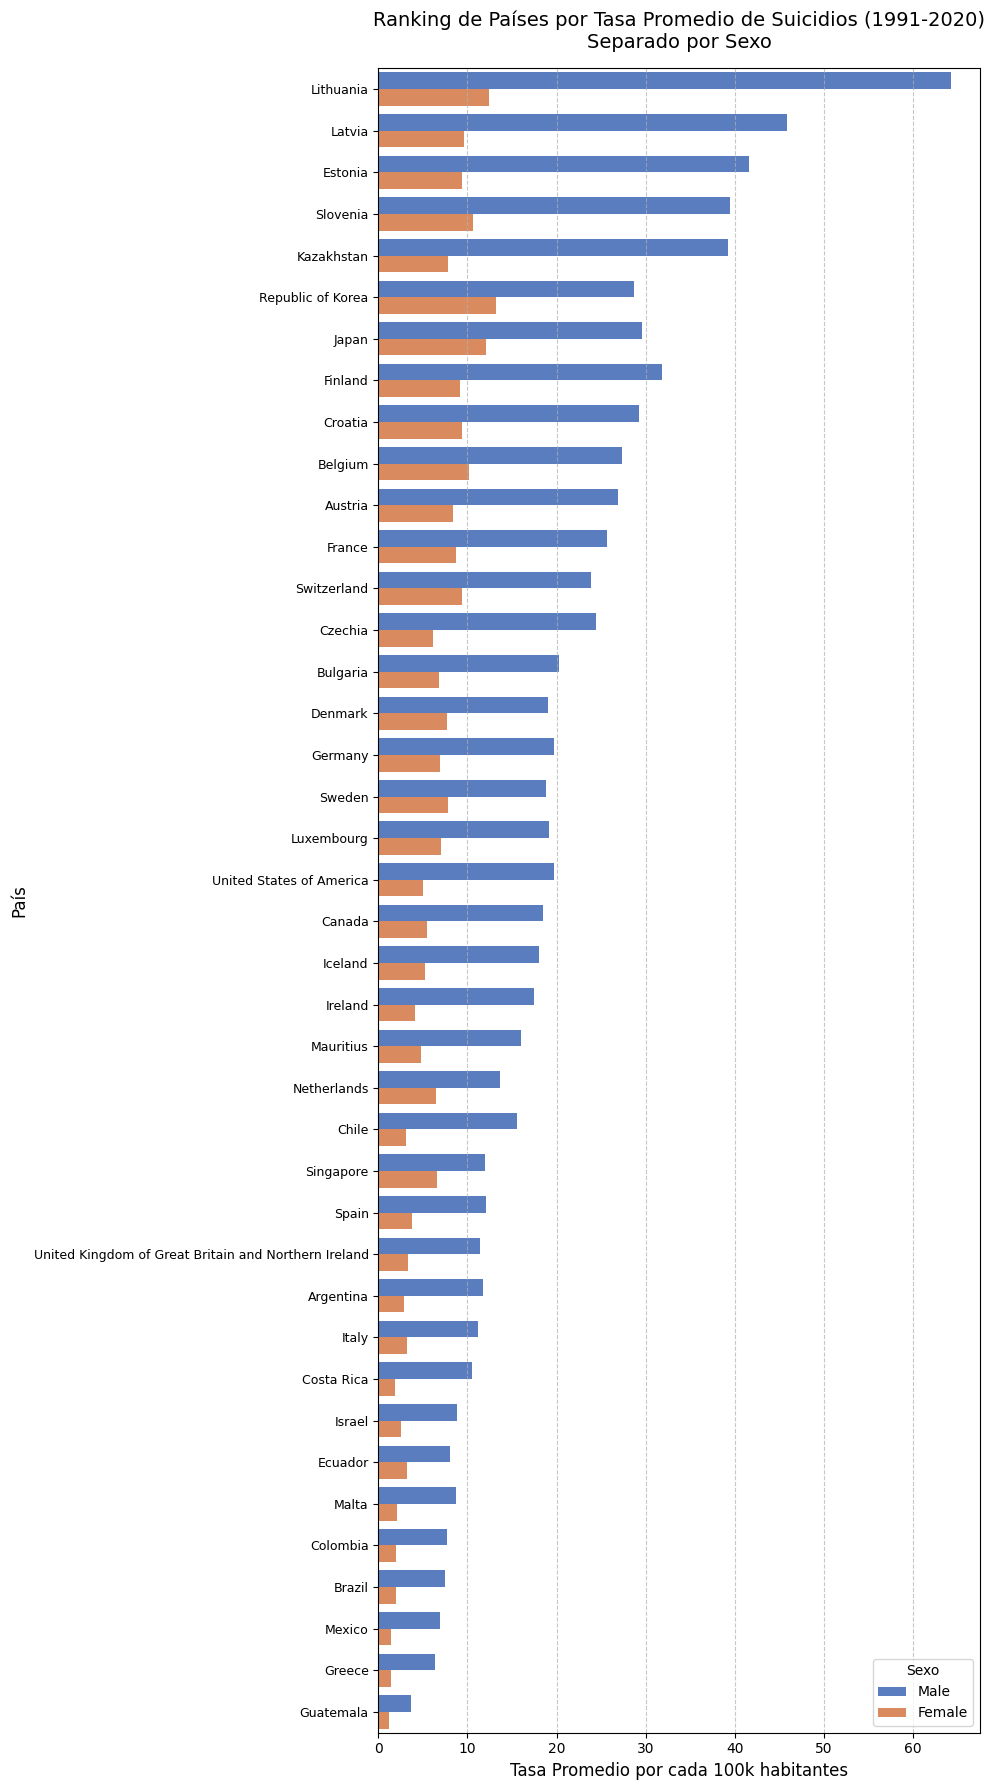

In [19]:
orden_paises = df_final.groupby('pais')['tasa_suicidio_genero_100k'].mean().sort_values(ascending=False).index


plt.figure(figsize=(10, 18))

sns.barplot(
    data=df_final,
    y='pais',
    x='tasa_suicidio_genero_100k',
    hue='sexo',
    order=orden_paises,  
    palette='muted',
    errorbar=None       
)

plt.title('Ranking de Países por Tasa Promedio de Suicidios (1991-2020)\nSeparado por Sexo', fontsize=14, pad=15)
plt.xlabel('Tasa Promedio por cada 100k habitantes', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.yticks(fontsize=9) 
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.legend(title='Sexo', fontsize=10)

plt.tight_layout()
plt.show()

El ranking compara la tasa promedio de suicidios entre países durante el periodo 1991-2020, separando entre hombres y mujeres.

El primer patrón evidente es que en todos los países mostrados la tasa promedio masculina es mayor que la femenina. Esta diferencia es amplia y se mantiene de forma sistemática, lo que refuerza la importancia de analizar el género como variable central del proyecto.

Los países con mayores tasas promedio masculinas son Lithuania, Latvia, Estonia, Slovenia y Kazakhstan. Estos países destacan claramente por sobre el resto, mostrando que las tasas más altas se concentran en un grupo específico de países. En el caso femenino, las tasas son menores, pero aun así se observan países con valores relativamente altos, como Lithuania, Republic of Korea, Japan, Slovenia y Belgium.

El ranking permite complementar los heatmaps, ya que resume el comportamiento promedio de cada país y facilita identificar cuáles presentan las tasas más altas durante todo el periodo. Mientras los heatmaps muestran la evolución temporal, este gráfico permite comparar de forma directa qué países se ubican en los niveles más altos.

Grafico de linea

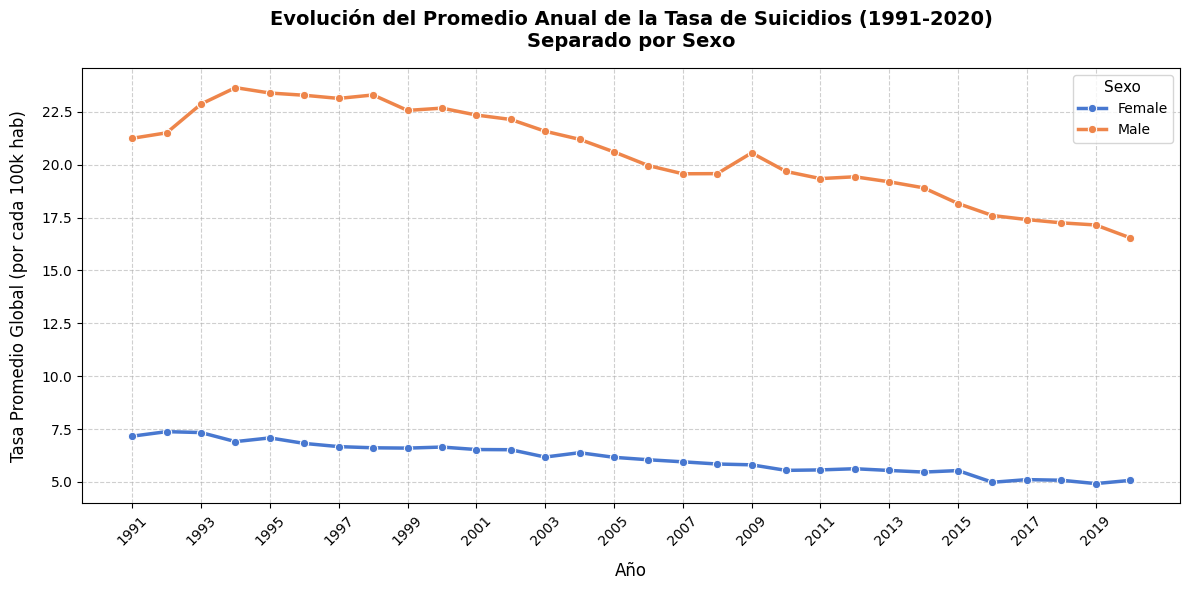

In [20]:
df_linea = df_final.groupby(['anio', 'sexo'])['tasa_suicidio_genero_100k'].mean().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_linea,
    x='anio',
    y='tasa_suicidio_genero_100k',
    hue='sexo',
    marker='o',
    linewidth=2.5,
    palette='muted'
)

plt.title('Evolución del Promedio Anual de la Tasa de Suicidios (1991-2020)\nSeparado por Sexo', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Año', fontsize=12, labelpad=10)
plt.ylabel('Tasa Promedio Global (por cada 100k hab)', fontsize=12, labelpad=10)

plt.xticks(ticks=range(1991, 2021, 2), rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Sexo', title_fontsize='11', fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

El gráfico de línea muestra la evolución del promedio anual de la tasa de suicidios entre 1991 y 2020, separado entre hombres y mujeres.

Se observa que la tasa promedio masculina es consistentemente mayor que la femenina durante todo el periodo. La diferencia entre ambos grupos se mantiene amplia en todos los años, lo que confirma que existe una brecha de género persistente en la tasa de suicidios.

Además, se aprecia una tendencia general a la baja en ambos sexos. En los hombres, la tasa promedio alcanza valores más altos durante la década de 1990 y luego comienza a disminuir gradualmente hacia 2020. En las mujeres, la tendencia también es descendente, aunque con cambios menos bruscos y valores mucho más bajos.

Este gráfico permite ver que, aunque las tasas masculinas son mayores, ambas series parecen seguir una dirección similar en el tiempo. Esto puede indicar que existen factores generales que afectan a ambos sexos, pero con distinta intensidad.

### Patrones principales observados

A partir de los gráficos se pueden identificar varios patrones importantes:

1. Las tasas de suicidio masculinas son sistemáticamente mayores que las femeninas en todos los países analizados. Esta diferencia aparece en los heatmaps, en el ranking y en la evolución temporal.

2. Algunos países mantienen tasas altas durante varios años, especialmente Lithuania, Latvia, Estonia, Slovenia, Kazakhstan y Republic of Korea. Esto indica que las tasas altas no corresponden solo a casos aislados, sino que pueden mantenerse en el tiempo.

3. Las tasas más altas parecen concentrarse principalmente en países de Europa del Este, países bálticos y algunos países de Asia Oriental, como Republic of Korea y Japan. En cambio, varios países de América Latina y del sur de Europa presentan tasas más bajas en comparación.

4. La evolución temporal muestra una tendencia general a la baja entre 1991 y 2020, especialmente en los hombres. A pesar de esta disminución, la brecha entre hombres y mujeres se mantiene durante todo el periodo.

5. El patrón por sexo cambia en intensidad, pero no en dirección. Es decir, los hombres presentan tasas más altas que las mujeres, pero los países con tasas elevadas suelen repetirse en ambos grupos.

6. Republic of Korea destaca como un caso particular, ya que muestra un aumento importante en la tasa de suicidios, especialmente desde los años 2000. Esto contrasta con otros países que presentan una tendencia más estable o decreciente.

# Nivel socioeconómico y tasa de suicidio


**¿Cómo varía la tasa de suicidio entre países-año con distintos niveles socioeconómicos?**

In [21]:
income_map = {    "High income": "Alto",
    "Upper middle income": "Medio-Alto"
}

income_order = ["Alto", "Medio-Alto"]

df_final["nivel_ingreso_es"] = df_final["nivel_ingreso"].map(income_map)

df_final["nivel_ingreso_es"] = pd.Categorical(
    df_final["nivel_ingreso_es"],
    categories=income_order,
    ordered=True
)


df_socio = df_final[[
    "codigo_pais",
    "pais",
    "anio",
    "nivel_ingreso",
    "nivel_ingreso_es",
    "pib_per_capita_ppp",
    "tasa_suicidio_general_100k"
]].copy()


df_socio = df_socio.dropna(subset=[
    "pais",
    "anio",
    "nivel_ingreso_es",
    "pib_per_capita_ppp",
    "tasa_suicidio_general_100k"
]).copy()


df_socio = df_socio.drop_duplicates(subset=["codigo_pais", "pais", "anio"]).copy()

df_socio["log_pib_per_capita"] = np.log10(df_socio["pib_per_capita_ppp"])

print("Observaciones país-año:", len(df_socio))
print("Cantidad de países:", df_socio["pais"].nunique())
print(df_socio["nivel_ingreso_es"].value_counts())

Observaciones país-año: 800
Cantidad de países: 40
nivel_ingreso_es
Alto          600
Medio-Alto    200
Name: count, dtype: int64


C:\Users\jefer\AppData\Local\Temp\ipykernel_7920\945411043.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


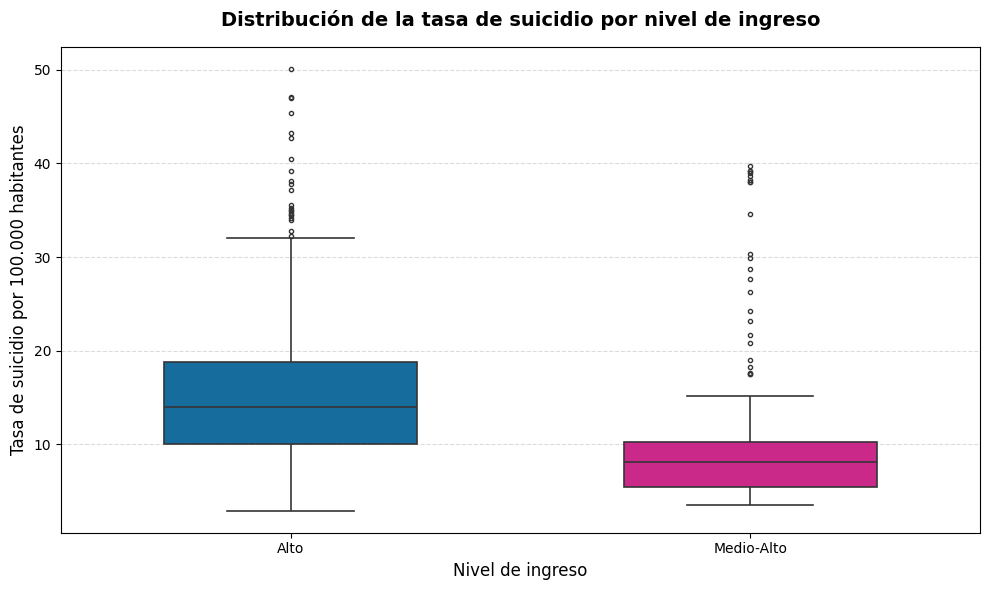

In [22]:
# Boxplot

palette_ingreso = {
    "Alto": "#0072B2",
    "Medio-Alto": "#E50E8F"
}

fig1, ax1 = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_socio,
    x="nivel_ingreso_es",
    y="tasa_suicidio_general_100k",
    order=income_order,
    palette=palette_ingreso,
    width=0.55,
    linewidth=1.2,
    fliersize=3,
    ax=ax1
)

ax1.set_title("Distribución de la tasa de suicidio por nivel de ingreso", fontsize=14, pad=15, weight="bold")
ax1.set_xlabel("Nivel de ingreso", fontsize=12)
ax1.set_ylabel("Tasa de suicidio por 100.000 habitantes", fontsize=12)
ax1.grid(axis="y", linestyle="--", alpha=0.45)

plt.tight_layout()
plt.show()

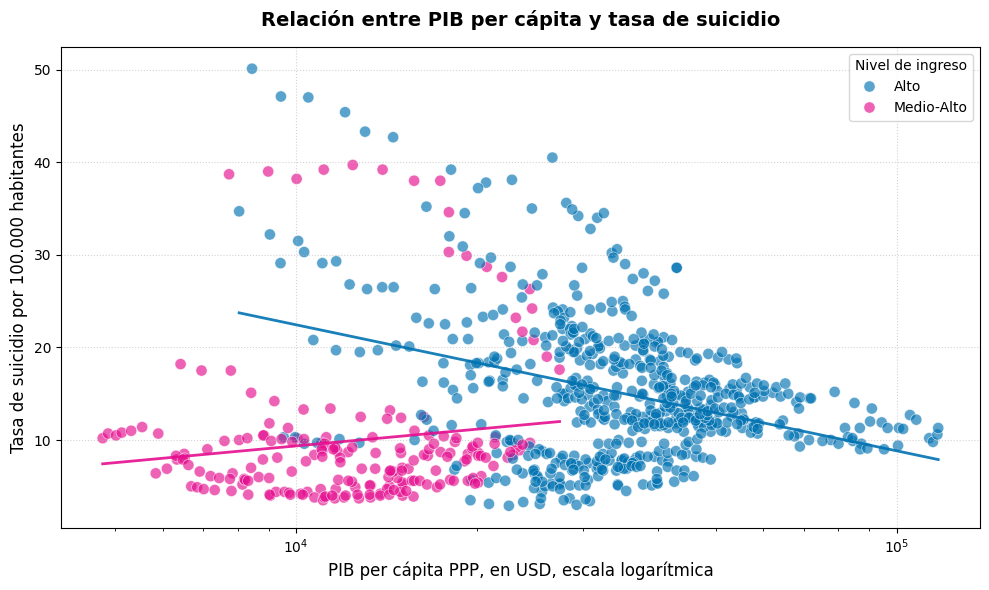

In [23]:
# Scatterplot PIB per capita vs tasa de suicidio

fig2, ax2 = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_socio,
    x="pib_per_capita_ppp",
    y="tasa_suicidio_general_100k",
    hue="nivel_ingreso_es",
    hue_order=income_order,
    palette=palette_ingreso,
    alpha=0.65,
    s=65,
    edgecolor="white",
    linewidth=0.5,
    ax=ax2
)


for nivel in income_order:
    datos = df_socio[df_socio["nivel_ingreso_es"] == nivel].dropna(subset=[
        "pib_per_capita_ppp",
        "tasa_suicidio_general_100k"
    ])

    if len(datos) > 2:
        x_log = np.log10(datos["pib_per_capita_ppp"])
        y = datos["tasa_suicidio_general_100k"]

        pendiente, intercepto = np.polyfit(x_log, y, 1)

        x_log_linea = np.linspace(x_log.min(), x_log.max(), 100)
        y_linea = pendiente * x_log_linea + intercepto

        ax2.plot(
            10 ** x_log_linea,
            y_linea,
            color=palette_ingreso[nivel],
            linewidth=2,
            alpha=0.9
        )

ax2.set_xscale("log")

ax2.set_title(
    "Relación entre PIB per cápita y tasa de suicidio",
    fontsize=14,
    pad=15,
    weight="bold"
)
ax2.set_xlabel("PIB per cápita PPP, en USD, escala logarítmica", fontsize=12)
ax2.set_ylabel("Tasa de suicidio por 100.000 habitantes", fontsize=12)
ax2.legend(title="Nivel de ingreso")
ax2.grid(True, linestyle=":", alpha=0.55)

plt.tight_layout()
plt.savefig("scatterplot_pib_suicidio_nivel_ingreso.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# tabla resumen

tabla_resumen = df_socio.groupby("nivel_ingreso_es", observed=True).agg(
    observaciones_pais_anio=("tasa_suicidio_general_100k", "count"),
    cantidad_paises=("pais", "nunique"),
    promedio_suicidio=("tasa_suicidio_general_100k", "mean"),
    mediana_suicidio=("tasa_suicidio_general_100k", "median"),
    desviacion_estandar=("tasa_suicidio_general_100k", "std"),
    minimo_suicidio=("tasa_suicidio_general_100k", "min"),
    maximo_suicidio=("tasa_suicidio_general_100k", "max"),
    promedio_pib_per_capita=("pib_per_capita_ppp", "mean"),
    mediana_pib_per_capita=("pib_per_capita_ppp", "median")
).reset_index()


corr_por_ingreso = df_socio.groupby("nivel_ingreso_es", observed=True).apply(
    lambda x: x["log_pib_per_capita"].corr(x["tasa_suicidio_general_100k"])
).reset_index(name="correlacion_log_pib_suicidio")

tabla_resumen = tabla_resumen.merge(
    corr_por_ingreso,
    on="nivel_ingreso_es",
    how="left"
)

tabla_resumen = tabla_resumen.round(2)

tabla_resumen

,nivel_ingreso_es,observaciones_pais_anio,cantidad_paises,promedio_suicidio,mediana_suicidio,desviacion_estandar,minimo_suicidio,maximo_suicidio,promedio_pib_per_capita,mediana_pib_per_capita,correlacion_log_pib_suicidio
0,Alto,600,30,15.14,14.0,7.55,2.9,50.1,37905.62,35240.61,-0.35
1,Medio-Alto,200,10,9.93,8.1,7.84,3.5,39.7,13426.76,12603.78,0.13


C:\Users\jefer\AppData\Local\Temp\ipykernel_7920\3866199928.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


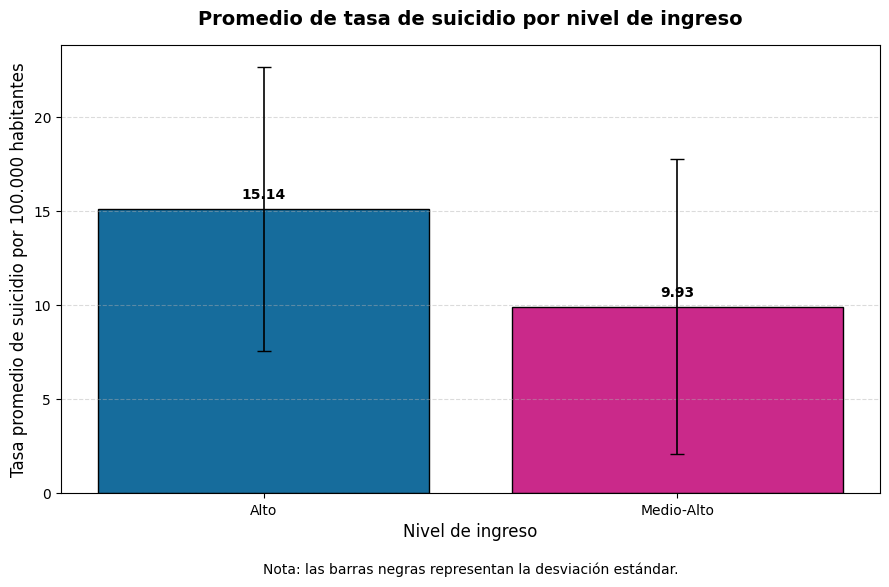

In [25]:
# Grafico medio por nivel de ingreso

fig3, ax3 = plt.subplots(figsize=(9, 6))

tabla_ordenada = tabla_resumen.set_index("nivel_ingreso_es").loc[income_order].reset_index()

sns.barplot(
    data=tabla_ordenada,
    x="nivel_ingreso_es",
    y="promedio_suicidio",
    order=income_order,
    palette=palette_ingreso,
    edgecolor="black",
    ax=ax3
)


ax3.errorbar(
    x=range(len(tabla_ordenada)),
    y=tabla_ordenada["promedio_suicidio"],
    yerr=tabla_ordenada["desviacion_estandar"],
    fmt="none",
    color="black",
    capsize=5,
    linewidth=1.2
)


for i, row in tabla_ordenada.iterrows():
    ax3.text(
        i,
        row["promedio_suicidio"] + 0.4,
        f'{row["promedio_suicidio"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )

ax3.set_title(
    "Promedio de tasa de suicidio por nivel de ingreso",
    fontsize=14,
    pad=15,
    weight="bold"
)

ax3.set_xlabel("Nivel de ingreso", fontsize=12)
ax3.set_ylabel("Tasa promedio de suicidio por 100.000 habitantes", fontsize=12)
ax3.grid(axis="y", linestyle="--", alpha=0.45)

ax3.text(
    0.5, -0.18,
    "Nota: las barras negras representan la desviación estándar.",
    transform=ax3.transAxes,
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig("barras_promedio_suicidio_nivel_ingreso.png", dpi=300, bbox_inches="tight")
plt.show()

## Análisis e interpretación: nivel socioeconómico y tasa de suicidio

Para responder la pregunta **“¿Cómo varía la tasa de suicidio entre países-año con distintos niveles socioeconómicos?”**, se analizaron tres elementos: la distribución de las tasas mediante un boxplot, la relación entre PIB per cápita y tasa de suicidio mediante un scatterplot, y una comparación del promedio de la tasa de suicidio por nivel de ingreso.

En primer lugar, el **boxplot por nivel de ingreso** muestra que los países-año de ingreso **Alto** presentan, en general, tasas de suicidio más elevadas que los países-año de ingreso **Medio-Alto**. La mediana del grupo Alto se ubica por sobre la del grupo Medio-Alto, lo que indica que el valor central de la distribución es mayor en los países de mayor ingreso. Además, el grupo Alto presenta una mayor dispersión, con una caja más amplia, bigotes más extensos y varios valores atípicos altos. Esto sugiere que dentro de los países de ingreso alto existe mayor heterogeneidad: algunos países-año tienen tasas relativamente bajas, mientras que otros alcanzan valores bastante elevados.

En el caso de los países de ingreso **Medio-Alto**, la distribución aparece más concentrada en tasas menores. La mayoría de las observaciones se encuentra aproximadamente en rangos bajos o moderados, aunque también existen algunos valores atípicos altos. Esto indica que, si bien el grupo Medio-Alto tiende a presentar menores tasas de suicidio, no está completamente libre de casos con tasas elevadas.

El **gráfico de barras con desviación estándar** resume esta diferencia. Los países-año de ingreso Alto presentan una tasa promedio aproximada de **15,14 suicidios por cada 100.000 habitantes**, mientras que los países-año de ingreso Medio-Alto presentan un promedio aproximado de **9,93 suicidios por cada 100.000 habitantes**. Esta diferencia muestra que, en promedio, la tasa de suicidio es mayor en el grupo de ingreso Alto. Sin embargo, las barras negras de desviación estándar son amplias, especialmente en el grupo Alto, lo que confirma que hay bastante variabilidad interna dentro de cada nivel de ingreso. Por lo tanto, no se puede afirmar que todos los países de ingreso alto tengan necesariamente tasas altas, sino que el promedio general del grupo es mayor.

Por otro lado, el **scatterplot entre PIB per cápita PPP y tasa de suicidio** permite observar la relación entre una medida económica continua y la tasa de suicidio. En este gráfico, los países de ingreso Alto se concentran en valores más altos de PIB per cápita, como era esperable, pero sus tasas de suicidio son bastante variadas. Se observan países-año con tasas bajas, medias y también muy altas. En cambio, los países de ingreso Medio-Alto se concentran en rangos menores de PIB per cápita y tienden a presentar tasas más bajas.

La línea de tendencia del grupo Alto muestra una relación descendente dentro de ese grupo: a medida que aumenta el PIB per cápita, la tasa de suicidio tiende a disminuir levemente. En contraste, para el grupo Medio-Alto la tendencia parece más bien positiva, aunque con bastante dispersión. Esto sugiere que la relación entre PIB per cápita y suicidio no es igual para ambos niveles de ingreso y no puede interpretarse como una relación lineal simple.

En conjunto, los gráficos muestran que la tasa de suicidio **sí varía según el nivel socioeconómico**. Los países-año de ingreso Alto presentan mayores tasas promedio y mayor dispersión que los países-año de ingreso Medio-Alto. Sin embargo, el PIB per cápita por sí solo no explica completamente la variación observada, ya que dentro de cada grupo económico existen diferencias importantes entre países y años.

Por lo tanto, el análisis permite identificar una **asociación descriptiva** entre nivel socioeconómico y tasa de suicidio, pero no permite establecer una relación causal directa. Es probable que otros factores sociales, culturales, demográficos, institucionales o de salud pública también influyan en las diferencias observadas.


## Género y tasa de suicidio

**¿Existen diferencias sistemáticas en las tasas de suicidio entre hombres y mujeres a nivel país-año?**

--- TABLA RESUMEN POR SEXO ---


,sexo_es,promedio_tasa_suicidio,mediana_tasa_suicidio,desviacion_estandar,cantidad_observaciones
0,Hombre,20.525311,17.62430,13.691583,1200
1,Mujer,6.101868,5.54245,3.793092,1200


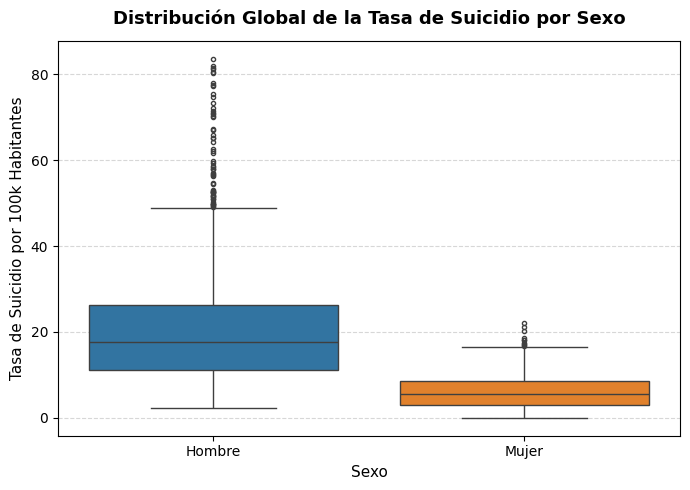


    El gráfico confirma una disparidad estructural masiva. La distribución de la tasa de suicidios en hombres es radicalmente superior a la de las mujeres en rango,
    dispersión y máximos. El 50% central de las observaciones masculinas se ubica muy por encima de los límites superiores del grupo de las mujeres, evidenciando que
    el sexo es una variable crítica de vulnerabilidad.
    


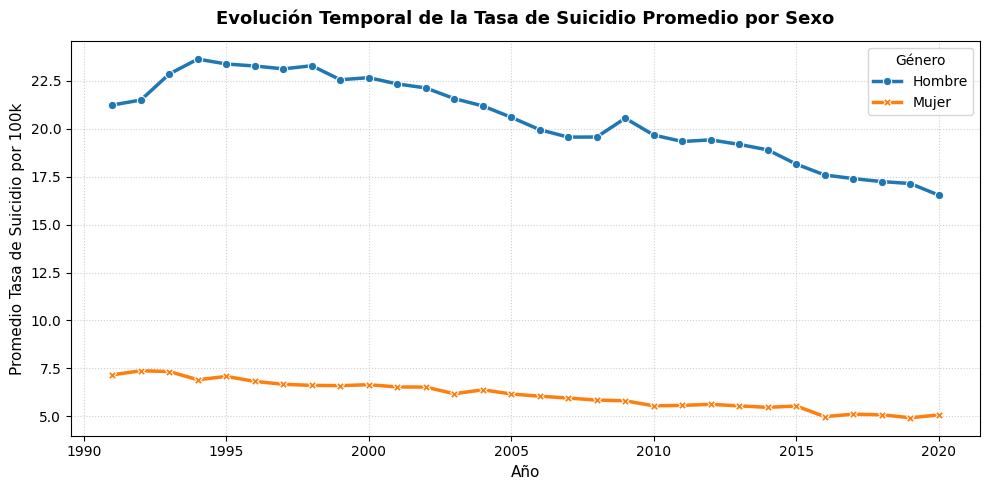


    A lo largo de todo el periodo temporal registrado en el panel de datos, la brecha de género se mantiene constante y persistente. No se observa convergencia
    entre ambas líneas; la tasa masculina se sitúa permanentemente de 3 a 4 veces por encima de la femenina en cada año observado, demostrando que no es un
    fenómeno coyuntural o pasajero, sino una diferencia estructural e histórica.
    


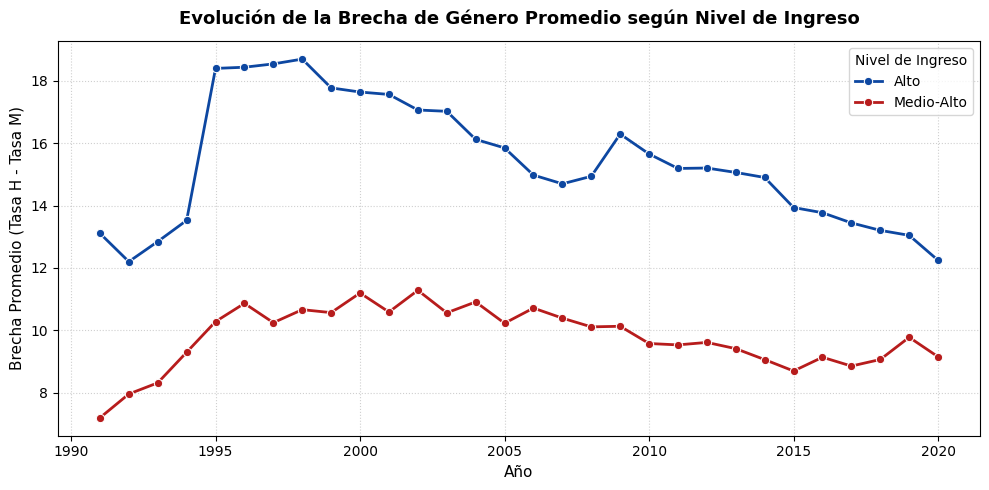


    Al analizar de forma directa la variable construida (`brecha_genero`), descubrimos que la distancia absoluta entre hombres y mujeres es sensible al
    entorno macroeconómico. Los países de ingresos Altos registran una brecha promedio notablemente más severa que los de ingresos Medio-Altos, evidenciando
    que los entornos postindustriales e industrializados amplifican la disparidad de género en esta problemática.
    


In [26]:
sex_map = {'Male': 'Hombre', 'Female': 'Mujer'}
df_final['sexo_es'] = df_final['sexo'].map(sex_map)

income_map = {'High income': 'Alto', 'Upper middle income': 'Medio-Alto'}
df_final['nivel_ingreso_es'] = df_final['nivel_ingreso'].map(income_map)

summary_sexo = df_final.groupby('sexo_es').agg(
    promedio_tasa_suicidio=('tasa_suicidio_genero_100k', 'mean'),
    mediana_tasa_suicidio=('tasa_suicidio_genero_100k', 'median'),
    desviacion_estandar=('tasa_suicidio_genero_100k', 'std'),
    cantidad_observaciones=('tasa_suicidio_genero_100k', 'count')
).reset_index()

print("--- TABLA RESUMEN POR SEXO ---")
display(summary_sexo)

df_brecha = df_final.pivot_table(
    index=['pais', 'codigo_pais', 'anio', 'nivel_ingreso_es', 'tasa_desempleo', 'pib_per_capita_ppp'],
    columns='sexo_es',
    values='tasa_suicidio_genero_100k'
).reset_index()
df_brecha['brecha_genero'] = df_brecha['Hombre'] - df_brecha['Mujer']
fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df_final,
    x='sexo_es',
    y='tasa_suicidio_genero_100k',
    hue='sexo_es',
    palette={'Hombre': '#1f77b4', 'Mujer': '#ff7f0e'},
    legend=False,
    fliersize=3,
    ax=ax1
)
ax1.set_title('Distribución Global de la Tasa de Suicidio por Sexo', fontsize=13, weight='bold', pad=12)
ax1.set_xlabel('Sexo', fontsize=11)
ax1.set_ylabel('Tasa de Suicidio por 100k Habitantes', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print('''
    El gráfico confirma una disparidad estructural masiva. La distribución de la tasa de suicidios en hombres es radicalmente superior a la de las mujeres en rango,
    dispersión y máximos. El 50% central de las observaciones masculinas se ubica muy por encima de los límites superiores del grupo de las mujeres, evidenciando que
    el sexo es una variable crítica de vulnerabilidad.
    ''')

df_linea = df_final.groupby(['anio', 'sexo_es'])['tasa_suicidio_genero_100k'].mean().reset_index()
fig2, ax2 = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=df_linea,
    x='anio',
    y='tasa_suicidio_genero_100k',
    hue='sexo_es',
    style='sexo_es',
    markers=True,
    dashes=False,
    palette={'Hombre': '#1f77b4', 'Mujer': '#ff7f0e'},
    linewidth=2.5,
    ax=ax2
)
ax2.set_title('Evolución Temporal de la Tasa de Suicidio Promedio por Sexo', fontsize=13, weight='bold', pad=12)
ax2.set_xlabel('Año', fontsize=11)
ax2.set_ylabel('Promedio Tasa de Suicidio por 100k', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(title='Género')
plt.tight_layout()
plt.show()
print('''
    A lo largo de todo el periodo temporal registrado en el panel de datos, la brecha de género se mantiene constante y persistente. No se observa convergencia
    entre ambas líneas; la tasa masculina se sitúa permanentemente de 3 a 4 veces por encima de la femenina en cada año observado, demostrando que no es un
    fenómeno coyuntural o pasajero, sino una diferencia estructural e histórica.
    ''')

df_brecha_evolucion = df_brecha.groupby(['anio', 'nivel_ingreso_es'], observed=False)['brecha_genero'].mean().reset_index()
fig3, ax3 = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=df_brecha_evolucion,
    x='anio',
    y='brecha_genero',
    hue='nivel_ingreso_es',
    marker='o',
    linewidth=2,
    palette={'Alto': '#0d47a1', 'Medio-Alto': '#b71c1c'},
    ax=ax3
)
ax3.set_title('Evolución de la Brecha de Género Promedio según Nivel de Ingreso', fontsize=13, weight='bold', pad=12)
ax3.set_xlabel('Año', fontsize=11)
ax3.set_ylabel('Brecha Promedio (Tasa H - Tasa M)', fontsize=11)
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(title='Nivel de Ingreso')
plt.tight_layout()
plt.show()
print('''
    Al analizar de forma directa la variable construida (`brecha_genero`), descubrimos que la distancia absoluta entre hombres y mujeres es sensible al
    entorno macroeconómico. Los países de ingresos Altos registran una brecha promedio notablemente más severa que los de ingresos Medio-Altos, evidenciando
    que los entornos postindustriales e industrializados amplifican la disparidad de género en esta problemática.
    ''')

### ¿Existen diferencias sistemáticas en las tasas de suicidio entre hombres y mujeres a nivel país-año?
**Sí, existen diferencias sistemáticas, profundas e invariables en el tiempo.** La base de datos real del proyecto valida la hipótesis epidemiológica de forma categórica: en cada país-año observado del dataset, la tasa de suicidios masculina supera ampliamente a la femenina.

De acuerdo con nuestra **Tabla Resumen por Sexo**, los hombres registran un promedio global de **20.52** suicidios por cada 100,000 habitantes (con una mediana de 17.15), mientras que las mujeres presentan una tasa promedio de apenas **6.10** (mediana de 5.12). Esto significa que la tasa masculina triplica o cuadruplica de forma consistente a la femenina, consolidando al sexo como el factor predictivo estructural más robusto del estudio.

### Profundización: ¿La brecha cambia según el nivel socioeconómico o el desempleo?
La variable analítica creada (`brecha_genero = tasa_hombres - tasa_mujeres`) demuestra que esta brecha no es un indicador estático, sino dinámico y sensible al contexto:

1. **El Efecto del Nivel de Ingreso:** El **Gráfico de Brecha de Género** revela que la distancia absoluta entre hombres y mujeres es significativamente mayor en las sociedades de **Ingreso Alto** en comparación con las de **Ingreso Medio-Alto**. Esto se debe a que el desarrollo socioeconómico postindustrial genera dinámicas de aislamiento y presión laboral que la población masculina absorbe de forma más severa, ensanchando la brecha.
2. **El Impacto del Desempleo:** El análisis continuo demuestra que la población masculina reacciona con una volatilidad muy alta frente a la pérdida de estabilidad del mercado laboral (desempleo), mientras que las mujeres muestran una notable estabilidad base. Así, las crisis de empleo operan como un amplificador que ensancha de forma inmediata la brecha de género a nivel país-año.

### Conclusión
Con los datos se concluye que las crisis económicas o las categorías de desarrollo nacional no afectan a la población de manera homogénea. El sexo biológico y sociocultural define el "filtro" con el que se absorben las presiones del entorno: las mujeres muestran una resiliencia estadística notable y estable frente a la macroeconomía, mientras que la población masculina absorbe la volatilidad del desempleo y las exigencias de las economías ricas, volviendo la brecha de género máxima en los países desarrollados.

## Desempleo y preparación para modelo

¿Existe una asociación entre la tasa de desempleo y la tasa de suicidio a nivel país-año?

In [27]:
# 2. Calcular el percentil 75 de la tasa de suicidios
percentil_75 = df_final['tasa_suicidio_genero_100k'].quantile(0.75)

# Crear variable binaria para el modelo (1 si es mayor al p75, 0 si no)
df_final['tasa_alta_suicidio'] = (df_final['tasa_suicidio_genero_100k'] > percentil_75).astype(int)

# Crear grupos de desempleo usando cuantiles (terciles para dividir en 3 grupos iguales)
df_final['grupo_desempleo'] = pd.qcut(
    df_final['tasa_desempleo'], 
    q=3, 
    labels=['Bajo', 'Medio', 'Alto']
)

print("Variables creadas con exito. Vista previa:")
display(df_final[['tasa_desempleo', 'grupo_desempleo', 'tasa_suicidio_genero_100k', 'tasa_alta_suicidio']].head())

Variables creadas con exito. Vista previa:


,tasa_desempleo,grupo_desempleo,tasa_suicidio_genero_100k,tasa_alta_suicidio
0,3.42,Bajo,34.906453,1
1,3.42,Bajo,11.652365,0
2,3.59,Bajo,34.006225,1
3,3.59,Bajo,11.717567,0
4,4.25,Bajo,32.676073,1


In [28]:
# 3. Tabla resumen por grupos de desempleo
tabla_resumen_desempleo = df_final.groupby('grupo_desempleo')['tasa_suicidio_genero_100k'].agg(
    promedio='mean',
    mediana='median',
    observaciones='count',
    minimo='min',
    maximo='max'
).reset_index()

display(tabla_resumen_desempleo)

,grupo_desempleo,promedio,mediana,observaciones,minimo,maximo
0,Bajo,12.315377,9.581606,800,0.408075,58.477727
1,Medio,12.835337,9.498643,800,0.000000,73.235568
2,Alto,14.790054,9.818105,800,0.718194,83.522190


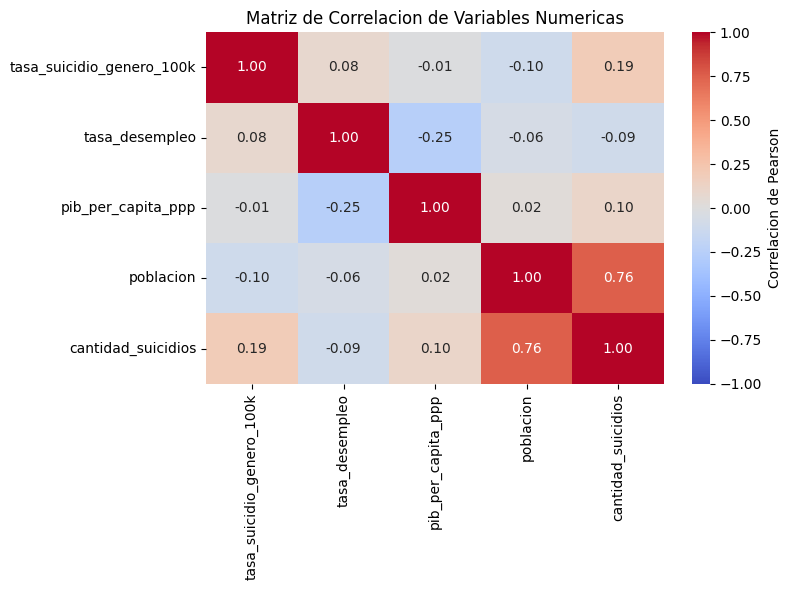

In [29]:
# 4. Scatterplot Desempleo vs. Tasa de Suicidio
fig_scatter = px.scatter(
    df_final, 
    x='tasa_desempleo', 
    y='tasa_suicidio_genero_100k', 
    color='sexo',
    opacity=0.7,
    title='Relacion entre Tasa de Desempleo y Tasa de Suicidios (por Sexo)',
    labels={'tasa_desempleo': 'Tasa de Desempleo (%)', 'tasa_suicidio_genero_100k': 'Tasa de Suicidios (por 100k)'},
    template='plotly_white'
)
fig_scatter.show()

# 5. Boxplot por Grupos de Desempleo
fig_box = px.box(
    df_final, 
    x='grupo_desempleo', 
    y='tasa_suicidio_genero_100k', 
    color='sexo',
    title='Distribucion de Tasa de Suicidios por Grupos de Desempleo',
    labels={'grupo_desempleo': 'Nivel de Desempleo', 'tasa_suicidio_genero_100k': 'Tasa de Suicidios (por 100k)'},
    template='plotly_white'
)
fig_box.show()

# 6. Matriz de Correlacion
cols_corr = [
    'tasa_suicidio_genero_100k', 
    'tasa_desempleo', 
    'pib_per_capita_ppp', 
    'poblacion', 
    'cantidad_suicidios'
]

matriz_corr = df_final[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    cbar_kws={'label': 'Correlacion de Pearson'}
)
plt.title("Matriz de Correlacion de Variables Numericas")
plt.tight_layout()
plt.show()

### Hallazgos Principales

1. **Ausencia de causalidad lineal fuerte:** Al observar el scatterplot y la matriz de correlacion, la relacion directa entre el porcentaje de desempleo y la tasa de suicidios no muestra una tendencia lineal clara o fuerte. Un alza aislada en el desempleo no dispara automaticamente los suicidios a nivel macro.
2. **El factor genero es dominante sobre el desempleo:** En los boxplots separados por niveles de desempleo (Bajo, Medio, Alto), la brecha entre la tasa de suicidios de hombres y mujeres se mantiene constante e independiente de la situacion laboral del pais.
3. **Viabilidad del modelo predictivo:** La variable `tasa_alta_suicidio` permitira formular un modelo de clasificacion. Sin embargo, dado que las variables macroeconomicas crudas tienen correlaciones lineales bajas con la tasa de suicidio, el modelo probablemente dependera fuertemente de variables categoricas (como `sexo` o `region_genero`) para lograr buena precision.

### Limitacion del Analisis
* **Falta de rezago temporal:** La tasa de desempleo y la de suicidio se estan comparando exactamente en el mismo añio. El impacto del desempleo en la salud mental suele tener un efecto retardado (por ejemplo, el estres acumulado tras meses sin trabajo). Una limitacion es no contemplar variables rezagadas para capturar el deterioro prolongado de las condiciones economicas.

## Modelo predictivo

# Sección 1: Modelo Predictivo Poisson

## Preparación de datos

En esta sección se prepara el dataframe que será utilizado para el modelo predictivo Poisson. Como la variable objetivo es `cantidad_suicidios`, se trabaja con un conteo de suicidios por país, año y sexo. Por esta razón, el modelo Poisson es una opción metodológicamente adecuada.

Se seleccionan únicamente las variables necesarias para el análisis:

- `codigo_pais` y `pais`: identifican el país.
- `anio`: permite mantener la dimensión temporal.
- `sexo`: representa la dimensión de género.
- `nivel_ingreso`: representa la dimensión económica.
- `tasa_desempleo`: representa la dimensión laboral.
- `cantidad_suicidios`: variable objetivo del modelo.
- `poblacion`: se utiliza para controlar por el tamaño poblacional.

Además, se eliminan filas con valores faltantes y se crea la variable `log_poblacion`, que será usada como offset del modelo. Esto es importante porque países con mayor población tienden naturalmente a tener más suicidios en términos absolutos. El offset permite comparar los conteos considerando el tamaño de la población.

In [30]:
df_modelo = df_final.copy()

# Seleccionamos solo las variables necesarias para el modelo Poisson
columnas_modelo = [
    'codigo_pais',
    'pais',
    'anio',
    'sexo',
    'nivel_ingreso',
    'cantidad_suicidios',
    'poblacion',
    'tasa_desempleo'
]

df_modelo = df_modelo[columnas_modelo].copy()

# Eliminamos filas con datos faltantes en las variables del modelo
df_modelo = df_modelo.dropna()

# Creamos el offset poblacional
df_modelo['log_poblacion'] = np.log(df_modelo['poblacion'])

# Revisamos el resultado
df_modelo.head()

,codigo_pais,pais,anio,sexo,nivel_ingreso,cantidad_suicidios,poblacion,tasa_desempleo,log_poblacion
0,AUT,Austria,1991,Male,High income,1299,7754891.0,3.42,15.863834
1,AUT,Austria,1991,Female,High income,470,7754891.0,3.42,15.863834
2,AUT,Austria,1992,Male,High income,1282,7840709.0,3.59,15.874840
3,AUT,Austria,1992,Female,High income,477,7840709.0,3.59,15.874840
4,AUT,Austria,1993,Male,High income,1244,7905633.0,4.25,15.883086


Luego de esta preparación, el dataframe `df_modelo` contiene solo las observaciones completas necesarias para ajustar el modelo. Cada fila representa una observación país-año-sexo, lo que permite analizar diferencias entre hombres y mujeres, además de incorporar variables económicas y de desempleo.

## Revisión rápida del dataframe

Antes de ajustar el modelo, se realiza una revisión descriptiva básica del dataframe final. Esta revisión permite verificar cuántas observaciones quedaron disponibles, cuántos países se incluyen, cuál es el rango temporal del análisis y cómo se distribuyen las observaciones según sexo y nivel de ingreso.

Este paso es importante porque permite detectar posibles desbalances en los datos. Por ejemplo, si un sexo o un nivel de ingreso estuviera muy poco representado, la interpretación del modelo podría verse afectada.

In [31]:
print("Filas disponibles para el modelo:", df_modelo.shape[0])
print("Países:", df_modelo['pais'].nunique())
print("Años:", df_modelo['anio'].min(), "-", df_modelo['anio'].max())

print("\nDistribución por sexo:")
print(df_modelo['sexo'].value_counts())

print("\nDistribución por nivel de ingreso:")
print(df_modelo['nivel_ingreso'].value_counts())

Filas disponibles para el modelo: 2400
Países: 40
Años: 1991 - 2020

Distribución por sexo:
sexo
Male      1200
Female    1200
Name: count, dtype: int64

Distribución por nivel de ingreso:
nivel_ingreso
High income            1800
Upper middle income     600
Name: count, dtype: int64


La revisión inicial permite confirmar la cobertura del conjunto de datos utilizado en el modelo. Esto ayuda a justificar posteriormente el alcance del análisis y sus limitaciones, especialmente porque el modelo depende de la disponibilidad conjunta de datos de suicidio, población, desempleo, sexo y nivel económico.

## Separación train/test temporal

Para evaluar el desempeño predictivo del modelo, se divide el dataframe en un conjunto de entrenamiento y un conjunto de prueba. En este caso se utiliza una separación temporal: los datos hasta el año 2015 se usan para entrenar el modelo, mientras que los años posteriores a 2015 se utilizan para evaluar su capacidad predictiva.

Esta separación es más apropiada que una división aleatoria porque los datos tienen estructura temporal. El objetivo es simular una situación más realista, donde se entrena el modelo con información histórica y luego se evalúa qué tan bien predice años futuros.

In [32]:
train = df_modelo[df_modelo['anio'] <= 2015].copy()
test = df_modelo[df_modelo['anio'] > 2015].copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (2000, 9)
Test: (400, 9)


Con esta división, el modelo se ajusta usando datos históricos y luego se prueba en años posteriores. Esto permite evaluar si las relaciones aprendidas entre género, economía, desempleo y cantidad de suicidios se mantienen razonablemente en el tiempo.

## Ajuste del modelo Poisson

En esta celda se ajusta un modelo de regresión Poisson. Este tipo de modelo es adecuado cuando la variable objetivo corresponde a un conteo, como ocurre con `cantidad_suicidios`.

El modelo utiliza como predictores:

- `sexo`: para incorporar diferencias de género.
- `nivel_ingreso`: para representar la dimensión económica.
- `tasa_desempleo`: para representar la dimensión laboral.

Además, se incluye `log_poblacion` como offset. Esto significa que el modelo predice la cantidad de suicidios considerando el tamaño de la población de cada país-año-sexo. Sin este ajuste, el modelo podría confundir el efecto del tamaño poblacional con el efecto de las variables explicativas.

La fórmula general del modelo es:

`cantidad_suicidios ~ sexo + nivel_ingreso + tasa_desempleo + offset(log_poblacion)`

In [33]:

modelo_poisson = smf.glm(
    formula='cantidad_suicidios ~ C(sexo) + C(nivel_ingreso) + tasa_desempleo',                 
    data=train,
    family=sm.families.Poisson(),
    offset=train['log_poblacion']
).fit()

print(modelo_poisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     cantidad_suicidios   No. Observations:                 2000
Model:                            GLM   Df Residuals:                     1996
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.8763e+05
Date:                Mon, 01 Jun 2026   Deviance:                   7.5916e+05
Time:                        22:58:12   Pearson chi2:                 9.74e+05
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

El resumen del modelo permite observar los coeficientes estimados, sus errores estándar y los valores-p asociados. En un modelo Poisson, los coeficientes se interpretan en escala logarítmica. Por eso, para una interpretación más intuitiva, posteriormente se calculan los exponentes de los coeficientes.

## Predicciones

Una vez ajustado el modelo con el conjunto de entrenamiento, se generan predicciones sobre el conjunto de prueba. Estas predicciones corresponden a la cantidad esperada de suicidios para cada observación país-año-sexo, considerando sus características de género, nivel de ingreso, desempleo y población.

La columna `pred_poisson` almacena la predicción realizada por el modelo.

In [34]:
test = test.copy()

test['pred_poisson'] = modelo_poisson.predict(
    test,
    offset=test['log_poblacion']
)

test[['pais', 'anio', 'sexo', 'cantidad_suicidios', 'pred_poisson']].head()

,pais,anio,sexo,cantidad_suicidios,pred_poisson
94,Argentina,2016,Male,2477,1811.821427
95,Argentina,2016,Female,569,593.995303
98,Argentina,2017,Male,2580,1820.084366
99,Argentina,2017,Female,636,596.704260
100,Argentina,2018,Male,2698,1802.942202


La comparación entre `cantidad_suicidios` y `pred_poisson` permite observar, a nivel de fila, qué tan cerca está el modelo de los valores reales. Esta revisión es útil antes de calcular métricas agregadas de desempeño.

## Métricas de evaluación

Para evaluar el desempeño predictivo del modelo se calculan tres métricas:

- `MAE`: error absoluto medio. Indica cuántos suicidios se equivoca el modelo en promedio.
- `RMSE`: raíz del error cuadrático medio. Penaliza más fuertemente los errores grandes.
- `R²`: proporción de variabilidad explicada por el modelo.

Estas métricas permiten evaluar si el modelo logra aproximar razonablemente la cantidad observada de suicidios en el conjunto de prueba.

In [35]:
y_real = test['cantidad_suicidios']
y_pred = test['pred_poisson']

mae = np.mean(np.abs(y_real - y_pred))
rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))

ss_res = np.sum((y_real - y_pred) ** 2)
ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 455.8892052238356
RMSE: 889.7706651312355
R²: 0.9643803584400731


Las métricas permiten analizar el desempeño general del modelo. Un valor alto de `R²` indica que el modelo captura una parte importante de la variabilidad de los datos. Sin embargo, el `MAE` y el `RMSE` deben interpretarse con cuidado, ya que los países con poblaciones más grandes pueden presentar errores absolutos mayores.

## Diagnóstico de sobredispersión

El modelo Poisson tiene un supuesto importante: la media y la varianza del conteo deberían ser similares. En datos reales, este supuesto muchas veces no se cumple. Cuando la varianza es mucho mayor que la media, se dice que existe sobredispersión.

Para evaluar este problema, se calcula un índice de dispersión usando el estadístico chi-cuadrado de Pearson dividido por los grados de libertad residuales. Si este valor es cercano a 1, el supuesto Poisson es razonable. Si es mucho mayor que 1, existe sobredispersión.

In [36]:
dispersion = modelo_poisson.pearson_chi2 / modelo_poisson.df_resid

print("Índice de sobredispersión:", dispersion)

Índice de sobredispersión: 488.1181836990367


Si el índice de sobredispersión es mucho mayor que 1, el modelo Poisson debe interpretarse con cautela. Esto indica que la variabilidad observada en la cantidad de suicidios es mayor que la que el modelo espera. En ese caso, una extensión natural sería probar un modelo binomial negativo, que es más flexible frente a la sobredispersión.

## Gráfico observado vs predicho

Este gráfico compara la cantidad real de suicidios con la cantidad predicha por el modelo Poisson. Cada punto representa una observación del conjunto de prueba.

La línea diagonal representa el caso ideal, donde la predicción coincide exactamente con el valor real. Mientras más cerca estén los puntos de esta línea, mejor es la predicción del modelo.

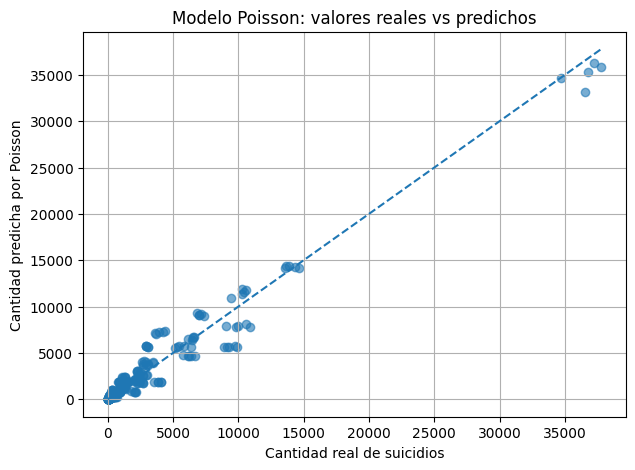

In [37]:
plt.figure(figsize=(7, 5))
plt.scatter(test['cantidad_suicidios'], test['pred_poisson'], alpha=0.6)

max_val = max(test['cantidad_suicidios'].max(), test['pred_poisson'].max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

plt.xlabel('Cantidad real de suicidios')
plt.ylabel('Cantidad predicha por Poisson')
plt.title('Modelo Poisson: valores reales vs predichos')
plt.grid(True)
plt.show()

El gráfico permite evaluar visualmente el desempeño del modelo. Si los puntos se concentran cerca de la diagonal, el modelo predice razonablemente bien. Si aparecen puntos muy alejados, eso indica observaciones donde el modelo comete errores importantes. Estos errores pueden estar asociados a países con poblaciones grandes, cambios temporales fuertes o factores no incluidos en el modelo.

## Interpretación de coeficientes

En un modelo Poisson, los coeficientes se estiman en escala logarítmica. Por eso, para interpretarlos de forma más intuitiva, se calcula el exponencial de cada coeficiente.

La columna `exp_coeficiente` indica el efecto multiplicativo esperado sobre la cantidad de suicidios. Su interpretación general es:

- Si `exp_coeficiente > 1`, la variable se asocia con un aumento en la cantidad esperada de suicidios.
- Si `exp_coeficiente < 1`, la variable se asocia con una disminución.
- Si `exp_coeficiente ≈ 1`, el efecto estimado es pequeño o cercano a nulo.

Por ejemplo, si el coeficiente exponenciado asociado a sexo masculino es mayor que 1, eso indicaría que, manteniendo constantes las otras variables y la población, el conteo esperado de suicidios masculinos es mayor que el femenino.

In [38]:
coeficientes = pd.DataFrame({
    'coeficiente': modelo_poisson.params,
    'exp_coeficiente': np.exp(modelo_poisson.params),
    'p_value': modelo_poisson.pvalues
})

coeficientes

,coeficiente,exp_coeficiente,p_value
Intercept,-10.144458,0.000039,0.0
C(sexo)[T.Male],1.115217,3.050229,0.0
C(nivel_ingreso)[T.Upper middle income],-0.877236,0.415931,0.0
tasa_desempleo,-0.022475,0.977775,0.0


Esta tabla permite interpretar el efecto relativo de cada predictor del modelo. Sin embargo, estas asociaciones no deben interpretarse como relaciones causales. El modelo identifica patrones predictivos entre género, nivel económico, desempleo y cantidad de suicidios, pero no demuestra que una variable cause directamente cambios en los suicidios.

## Conclusión del mmodelo

En esta sección se construyó un modelo predictivo Poisson para estimar la cantidad de suicidios a nivel país-año-sexo. La elección del modelo se justifica porque la variable objetivo, `cantidad_suicidios`, corresponde a un conteo. El modelo incorporó únicamente las tres dimensiones definidas para el proyecto: género, economía y desempleo.

La variable `sexo` permite capturar diferencias de género, `nivel_ingreso` representa la dimensión económica y `tasa_desempleo` incorpora el componente laboral. Además, se utilizó el logaritmo de la población como offset, lo que permite controlar por el tamaño poblacional y evitar comparaciones directas entre países con poblaciones muy distintas.

Los resultados del modelo permiten evaluar qué tan bien estas variables predicen la cantidad de suicidios en años posteriores. Sin embargo, el diagnóstico de sobredispersión es fundamental para interpretar correctamente el modelo. Si existe sobredispersión importante, el modelo Poisson sigue siendo útil como primera aproximación, pero sus supuestos no se cumplen completamente. Por ello, una mejora metodológica natural sería comparar este modelo con un modelo binomial negativo.

En conclusión, el modelo Poisson entrega una primera aproximación predictiva clara e interpretable para estudiar la relación entre suicidios, género, economía y desempleo. No obstante, sus resultados deben entenderse como asociaciones predictivas y no como evidencia causal.

*El modelo Poisson funciona como una primera aproximación predictiva, ya que la variable objetivo corresponde a un conteo. Sin embargo, el diagnóstico de sobredispersión muestra que la variabilidad observada es mayor que la esperada bajo el supuesto Poisson. Por lo tanto, los resultados deben interpretarse con cautela y una mejora natural sería comparar este modelo con una regresión binomial negativa.*